In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import glide.calibration.radiation as r
from glide.common_components.utils import circular_mask
import os
from concurrent.futures import ProcessPoolExecutor
import multiprocessing

def get_filenames(directory):
    paths = []
    for filenames in os.listdir(directory):
        paths.append(os.path.join(directory, filenames))
    return paths

def get_radiation_data(filepath, mask_fov, mask_cnr):
        ds = xr.open_dataset(filepath)
        ims = ds["images"]
        t_int = ds["t_int"].values
        aps_rad, mcp_rad, scaling_factor, mcp_gain = r.retrieve_radiation(ims, mask_fov, mask_cnr, t_int)
        ds.close()
        return aps_rad, mcp_rad, scaling_factor, mcp_gain

def main():
    # Generate FOV & CNR masks, 260 pixels is entirely within FOV, 300 pixels intrudes into all corners
    npix = 512
    fov_radius = 260
    cnr_radius = 300
    mask_fov = circular_mask(npix, fov_radius)
    mask_cnr = circular_mask(npix, cnr_radius, do_inverse=True)
    filepaths = get_filenames('data\\WFI_1A-DRK')

    # Init arrays for storing radiation data
    aps_rads, mcp_rads, scaling_factors, mcp_gains = [], [], [], []

    # Loop over files and calculate radiation data
    for i, filepath in enumerate(filepaths):
        aps_rad, mcp_rad, scaling_factor, mcp_gain = get_radiation_data(filepath, mask_fov, mask_cnr)
        aps_rads.append(aps_rad)
        mcp_rads.append(mcp_rad)
        scaling_factors.append(scaling_factor)
        mcp_gains.append(mcp_gain)

    # Convert lists to arrays after collecting all data
    aps_rads = np.concatenate(aps_rads)
    mcp_rads = np.concatenate(mcp_rads)
    scaling_factors = np.concatenate(scaling_factors)
    mcp_gains = np.concatenate(mcp_gains)

    # Plot data
    plt.scatter(mcp_rads, scaling_factors, s=1, label='MCP Radiation')
    plt.xlabel('MCP Radiation (W/m^2)')
    plt.ylabel('Scaling Factor')
    plt.title(f'MCP Radiation vs Scaling Factor for \n{filepaths[0]} thru \n{filepaths[-1]}')
    plt.legend()
    plt.show

    # Store aps_rad, mcp_rad, scaling_factor, mcp_gain, and source file data in xarray DataArray
    # Create a multi-index or simply use a sequential index
    da_aps = xr.DataArray(aps_rads, dims='observation')
    da_mcp = xr.DataArray(mcp_rads, dims='observation')
    da_scaling = xr.DataArray(scaling_factors, dims='observation')
    da_gain = xr.DataArray(mcp_gains, dims=('observation', 'rows', 'cols'))

    ds_output = xr.Dataset({'aps_rad': da_aps, 'mcp_rad': da_mcp, 'scaling_factor': da_scaling, 'mcp_gain': da_gain})
    ds_output.to_netcdf('radiation_data.nc')

main()

BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

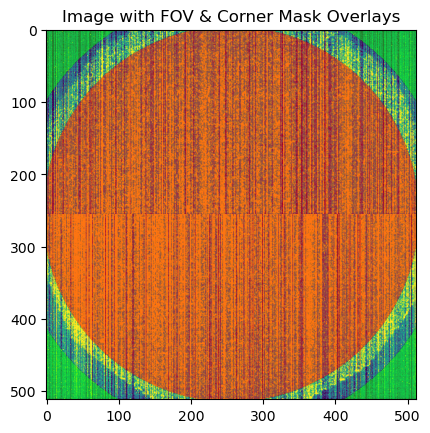

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import animation
import glide.calibration.radiation as rad
from glide.common_components.utils import circular_mask

# Load .nc
filename = 'data/WFI_1A-DRK/CARRUTHERS_GCI-WFI_L1A-DRK_20260119_v1.0.nc'
ds = xr.open_dataset(filename)
ims = ds["images"]
image = ims[0,:,:]

# Generate FOV & CNR masks, 260 pixels is entirely within FOV, 300 pixels intrudes into all corners
npix = 512
fov_radius = 260
cnr_radius = 300
mask_fov = circular_mask(npix, fov_radius)
mask_cnr = circular_mask(npix, cnr_radius, do_inverse=True)
t_int = ds["t_int"].values

# TESTING: Create colored arrays for overlay
overlay_color1 = np.zeros((*image.shape, 4)) # RGBA
overlay_color1[mask_fov] = [1, 0, 0, 1] # Red (R, G, B, A) - full opacity
overlay_color2 = np.zeros((*image.shape, 4)) # RGBA
overlay_color2[mask_cnr] = [0, 1, 0, 1] # Red (R, G, B, A) - full opacity

# Display the original image
plt.imshow(image, vmin=0, vmax=250000/30)
# Overlay the mask using imshow with an alpha value
plt.imshow(overlay_color1, alpha=0.5)
plt.imshow(overlay_color2, alpha=0.5)
plt.title('Image with FOV & Corner Mask Overlays')
plt.show()

MovieWriter stderr:
[vost#0:0 @ 0000025A5F590000] Unknown encoder 'libx264'
[vost#0:0 @ 0000025A5F590000] Error selecting an encoder
Error opening output file basic_animation.mp4.
Error opening output files: Encoder not found



CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '640x480', '-pix_fmt', 'rgba', '-framerate', '1', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-vcodec', 'libx264', '-y', 'basic_animation.mp4']' returned non-zero exit status 3165764104.

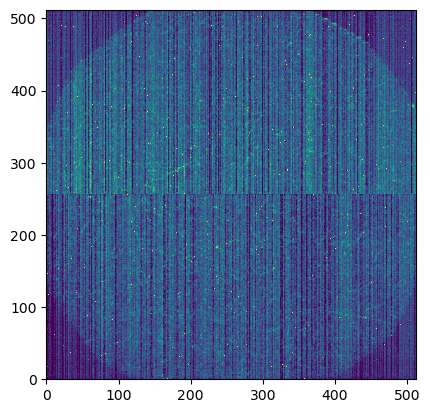

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib import animation
from glide.common_components.utils import circular_mask



# First set up the figure, the axis, and the plot element we want to animate
fig = plt.figure()
ax = plt.axes(xlim=(0, 512), ylim=(0, 512))
a=ims[0,:,:]
im=plt.imshow(a,interpolation='none', vmin=0, vmax=250000/10)

# initialization function: plot the background of each frame
def init():
    im.set_data(ims[0,:,:])
    return [im]

# animation function.  This is called sequentially
def animate(i):
    a=im.get_array()
    a=ims[i,:,:]    # update values with next frame data
    im.set_array(a)
    return [im]

# call the animator.  blit=True means only re-draw the parts that have changed.
anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=16, interval=10, blit=True)

# save the animation as an mp4.  This requires ffmpeg or mencoder to be
# installed.  The extra_args ensure that the x264 codec is used, so that
# the video can be embedded in html5.  You may need to adjust this for
# your system: for more information, see
# http://matplotlib.sourceforge.net/api/animation_api.html
anim.save('basic_animation.mp4', fps=1, extra_args=['-vcodec', 'libx264'])


In [ ]:
"""
Matplotlib Animation Example

author: Jake Vanderplas
email: vanderplas@astro.washington.edu
website: http://jakevdp.github.com
license: BSD
Please feel free to use and modify this, but keep the above information. Thanks!
"""

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import animation

# First set up the figure, the axis, and the plot element we want to animate
fig = plt.figure()
ax = plt.axes(xlim=(0, 2), ylim=(-2, 2))
line, = ax.plot([], [], lw=2)

# initialization function: plot the background of each frame
def init():
    line.set_data([], [])
    return line,

# animation function.  This is called sequentially
def animate(i):
    x = np.linspace(0, 2, 30)
    y = np.sin(2 * np.pi * (x - 0.01 * i))
    line.set_data(x, y)
    return line,

# call the animator.  blit=True means only re-draw the parts that have changed.
anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=200, interval=20, blit=True)

# save the animation as an mp4.  This requires ffmpeg or mencoder to be
# installed.  The extra_args ensure that the x264 codec is used, so that
# the video can be embedded in html5.  You may need to adjust this for
# your system: for more information, see
# http://matplotlib.sourceforge.net/api/animation_api.html
anim.save('basic_animation.mp4', fps=30, extra_args=['-vcodec', 'libx264'])

plt.show()